In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with correct text encoding
df = pd.read_csv(r"C:\Users\DELL\Downloads\Oasis_Infobyte_Projects\spam[1].csv", encoding='latin-1')

# Fix: Explicitly select only the first two useful columns and ignore the Unnamed ones
df = df[['v1', 'v2']]

# Rename them safely
df.columns = ['Category', 'Message']

print("\n--- CLEANED DATASET ---")
print(df.head())

print("\n--- CLASS DISTRIBUTION ---")
print(df['Category'].value_counts())


--- CLEANED DATASET ---
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

--- CLASS DISTRIBUTION ---
Category
ham     4825
spam     747
Name: count, dtype: int64


In [3]:
# Convert text labels to numbers: ham -> 0, spam -> 1
df['Label'] = df['Category'].map({'ham': 0, 'spam': 1})

from sklearn.model_selection import train_test_split

# X is our text message column, y is our numeric label
X = df['Message']
y = df['Label']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print(f"Messages for training: {len(X_train)}")
print(f"Messages for testing: {len(X_test)}")

Data split successfully!
Messages for training: 4457
Messages for testing: 1115


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Transform text strings into numerical word-frequency features
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# 2. Train the Naive Bayes Classifier
spam_model = MultinomialNB()
spam_model.fit(X_train_vectorized, y_train)

# 3. Predict classifications on your test data
y_pred = spam_model.predict(X_test_vectorized)

print(f"Spam Detection Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Spam Detection Accuracy: 96.59%


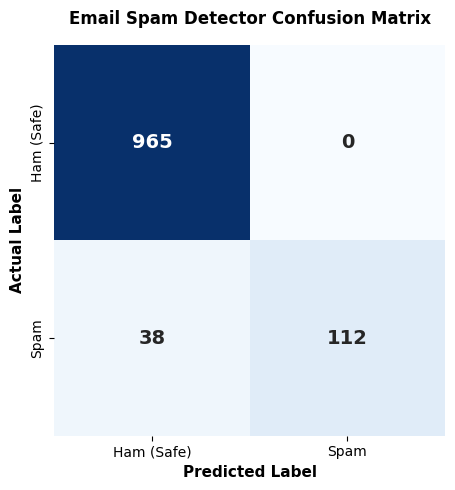

In [6]:
# Generate the math behind our predictions matrix
cm = confusion_matrix(y_test, y_pred)

# Build a professional heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Ham (Safe)', 'Spam'], 
            yticklabels=['Ham (Safe)', 'Spam'],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})

plt.title('Email Spam Detector Confusion Matrix', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()